In [1]:
# Загрузка данных
import pandas as pd
import os
import shutil
from google.colab import files
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()

!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python

with zipfile.ZipFile('customer-segmentation-tutorial-in-python.zip', 'r') as zip_ref:
    zip_ref.extractall('customer-segmentation-tutorial-in-python')
# Показать файлы в директории
print(os.listdir('customer-segmentation-tutorial-in-python'))

df = pd.read_csv('customer-segmentation-tutorial-in-python/Mall_Customers.csv')
# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# Выводим статистические данные о числовых столбцах
print(df.describe())

# Предобработка данных
# Кодируем Gender: Male -> 1, Female -> 0 (можно и OneHot, но для двух категорий достаточно бинарного)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Выделяем признаки для масштабирования
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values  # можно также оставить Gender, но тогда его тоже масштабировать не нужно

# Масштабируем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Для удобства можно создать DataFrame с масштабированными признаками
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.head())


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
  0% 0.00/1.55k [00:00<?, ?B/s]
100% 1.55k/1.55k [00:00<00:00, 7.01MB/s]
['Mall_Customers.csv']
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age       

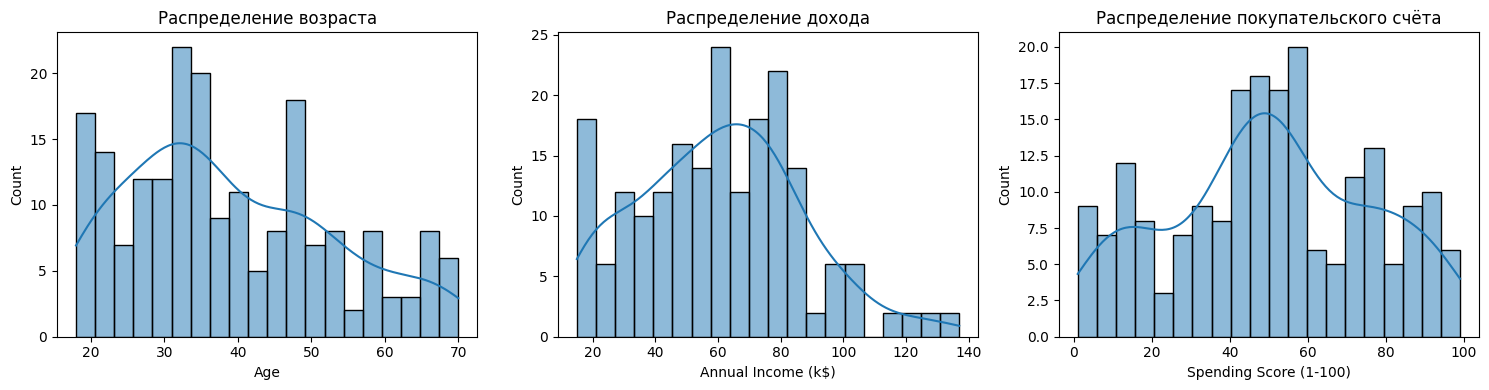

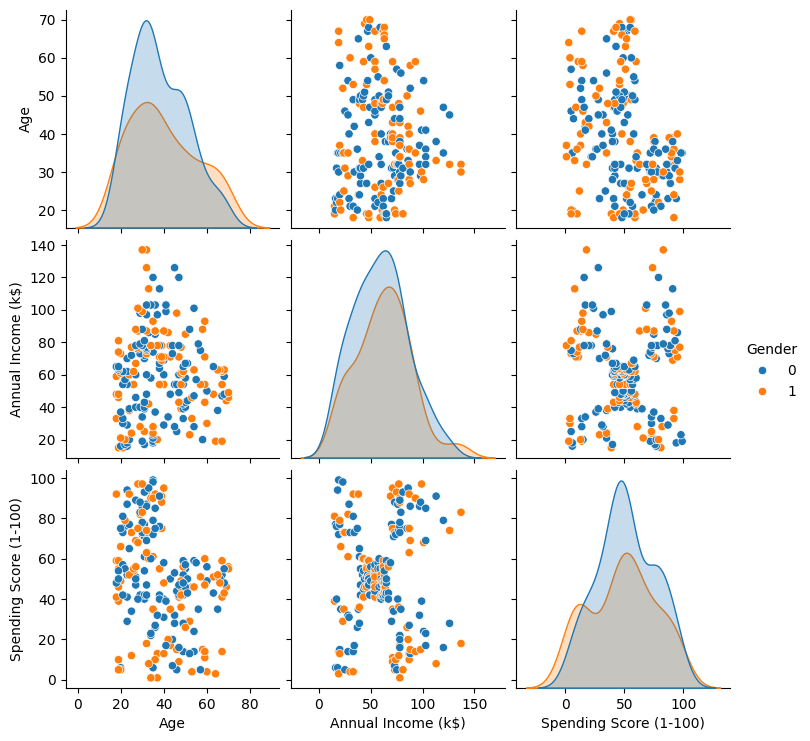

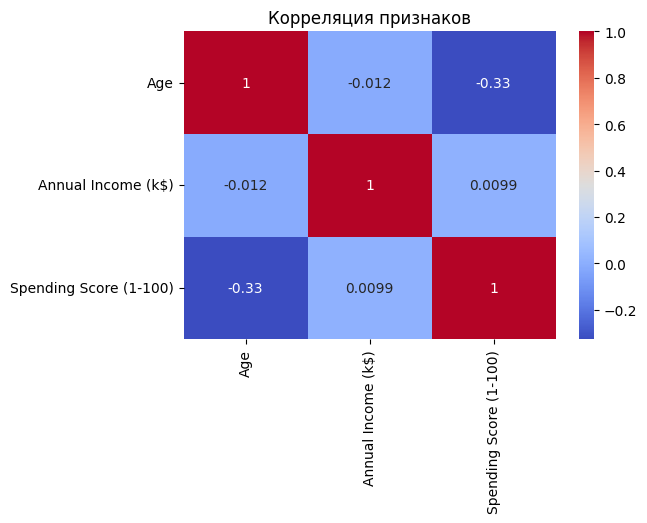

In [2]:
# Анализ EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Распределения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Распределение возраста')
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Распределение дохода')
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2])
axes[2].set_title('Распределение покупательского счёта')
plt.tight_layout()
plt.show()

# Pairplot с цветом по полу
sns.pairplot(df, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue='Gender')
plt.show()

# Корреляционная матрица
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

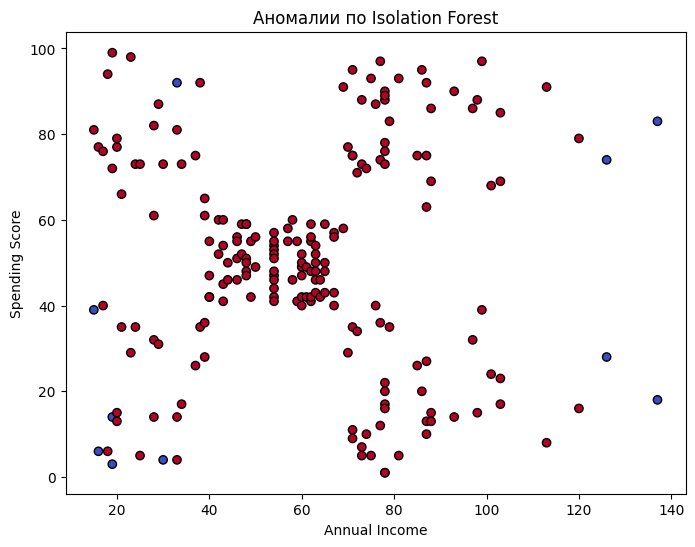

Найденные выбросы:
      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1       1   19                  15                      39   
2             3       0   20                  16                       6   
8             9       1   64                  19                       3   
10           11       1   67                  19                      14   
30           31       1   60                  30                       4   
33           34       1   18                  33                      92   
196         197       0   45                 126                      28   
197         198       1   32                 126                      74   
198         199       1   32                 137                      18   
199         200       1   30                 137                      83   

     Anomaly_IF  
0            -1  
2            -1  
8            -1  
10           -1  
30           -1  
33           -1  
196          -1  

In [3]:
# Поиск аномалий
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)  # предполагаем 5% аномалий
outliers = iso_forest.fit_predict(X_scaled)  # -1 для аномалий, 1 для нормы
df['Anomaly_IF'] = outliers

# Визуализация аномалий
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Anomaly_IF'], cmap='coolwarm', edgecolors='k')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Аномалии по Isolation Forest')
plt.show()
print("Найденные выбросы:\n", df[outliers == -1])

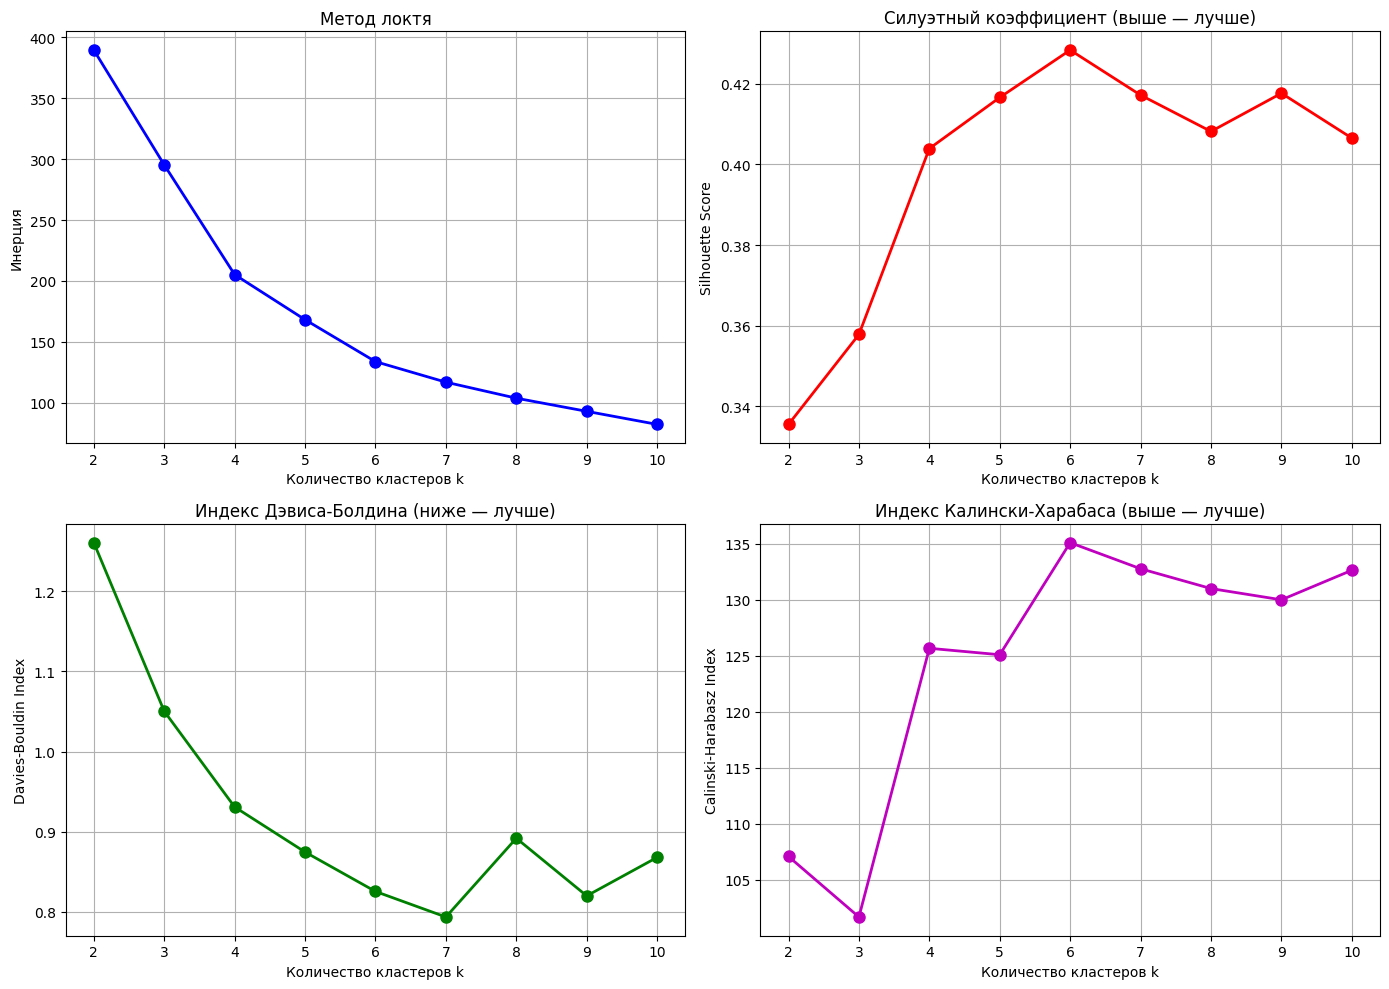

Оптимальное число кластеров по силуэту: 6


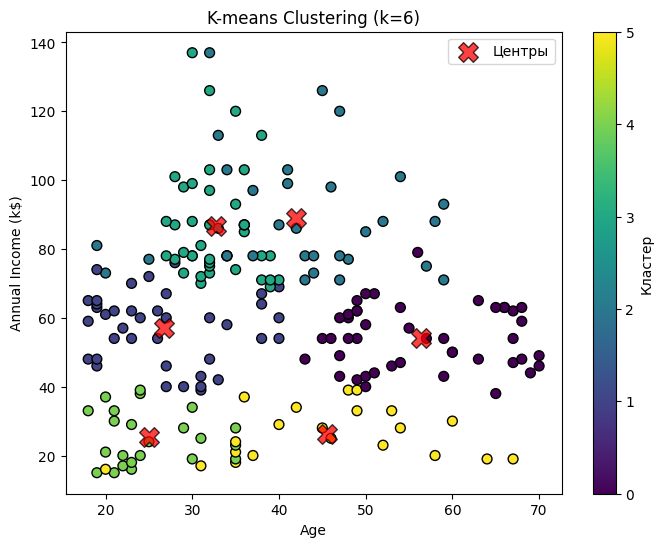


Метрики качества для KMeans (k = 6):
  Silhouette Score: 0.4284
  Davies-Bouldin Index: 0.8254
  Calinski-Harabasz Index: 135.1021


In [4]:
# Сегментация методом KMeans с анализом качества для разного числа кластеров
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np

# Диапазон k для проверки
k_range = range(2, 11)

# Списки для хранения метрик
inertia = []
silhouette = []
db_index = []
ch_index = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    db_index.append(davies_bouldin_score(X_scaled, labels))
    ch_index.append(calinski_harabasz_score(X_scaled, labels))

# Визуализация метрик
plt.figure(figsize=(14, 10))

# 1. Метод локтя
plt.subplot(2, 2, 1)
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров k')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.grid(True)

# 2. Силуэтный коэффициент
plt.subplot(2, 2, 2)
plt.plot(k_range, silhouette, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette Score')
plt.title('Силуэтный коэффициент (выше — лучше)')
plt.grid(True)

# 3. Индекс Дэвиса-Болдина
plt.subplot(2, 2, 3)
plt.plot(k_range, db_index, 'go-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров k')
plt.ylabel('Davies-Bouldin Index')
plt.title('Индекс Дэвиса-Болдина (ниже — лучше)')
plt.grid(True)

# 4. Индекс Калински-Харабаса
plt.subplot(2, 2, 4)
plt.plot(k_range, ch_index, 'mo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров k')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Индекс Калински-Харабаса (выше — лучше)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Выбор оптимального k (например, по максимуму силуэта)
best_k = k_range[np.argmax(silhouette)]
print(f"Оптимальное число кластеров по силуэту: {best_k}")

# Обучение KMeans с оптимальным k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = clusters_kmeans

# Визуализация результатов (первые два признака)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters_kmeans, s=50, cmap='viridis', edgecolors='k')

# Отображаем центры кластеров (преобразуем обратно в исходный масштаб)
centers_scaled = kmeans.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled)
plt.scatter(centers_orig[:, 0], centers_orig[:, 1], c='red', s=200, alpha=0.75, marker='X', edgecolors='k', label='Центры')

plt.title(f"K-means Clustering (k={best_k})")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.legend()
plt.colorbar(scatter, label='Кластер')
plt.show()

# Вывод метрик для выбранного k
print(f"\nМетрики качества для KMeans (k = {best_k}):")
print(f"  Silhouette Score: {silhouette[best_k-2]:.4f}")
print(f"  Davies-Bouldin Index: {db_index[best_k-2]:.4f}")
print(f"  Calinski-Harabasz Index: {ch_index[best_k-2]:.4f}")

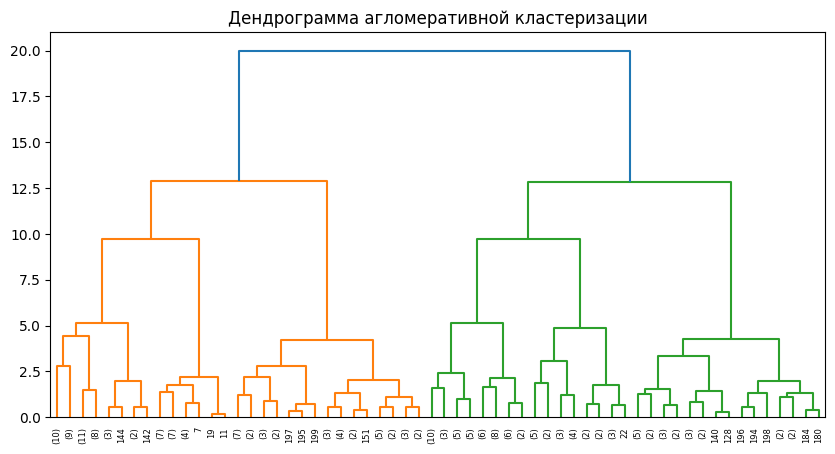

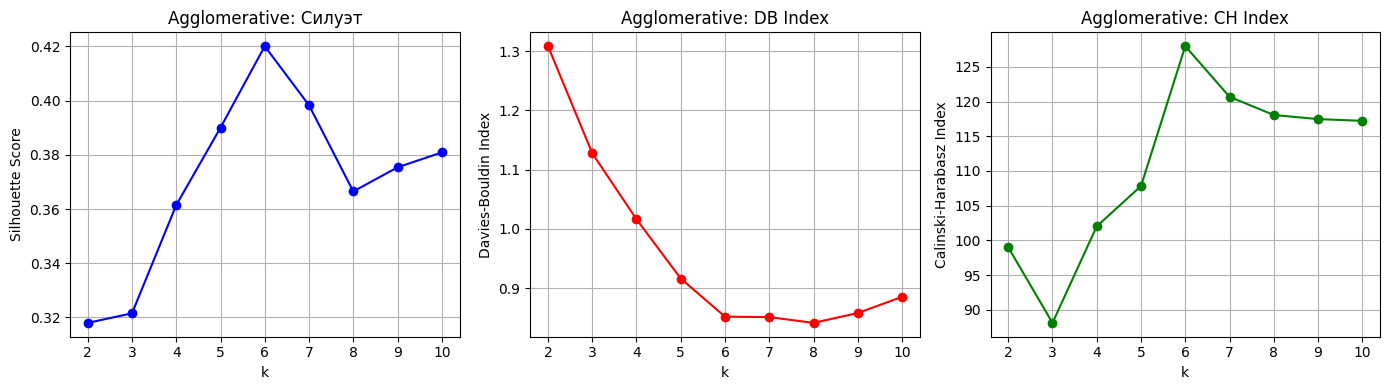

Оптимальное число кластеров для Agglomerative: 6


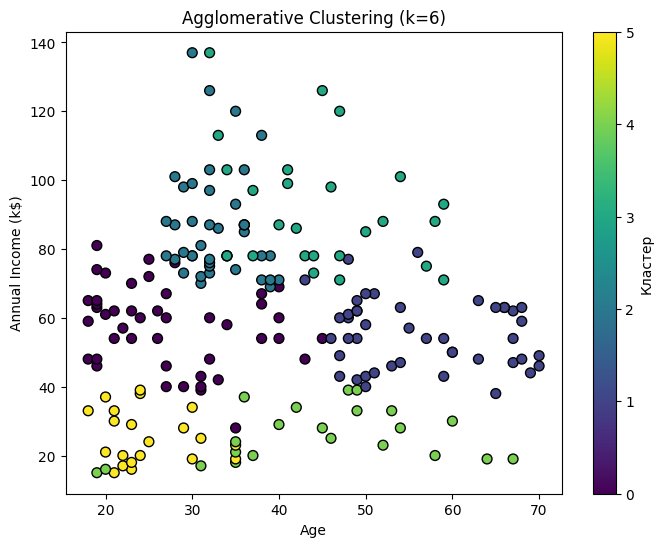

Метрики Agglomerative (k=6):
  Silhouette: 0.4201
  Davies-Bouldin: 0.8521
  Calinski-Harabasz: 127.9865


In [5]:
# Агломеративная кластеризация
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Диапазон k
k_range = range(2, 11)

# Списки для метрик
sil_agg = []
db_agg = []
ch_agg = []

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_scaled)
    sil_agg.append(silhouette_score(X_scaled, labels))
    db_agg.append(davies_bouldin_score(X_scaled, labels))
    ch_agg.append(calinski_harabasz_score(X_scaled, labels))
# Вычисление матрицы связей (метод Уорда)
linked = linkage(X_scaled, method='ward')

# Построение дендрограммы
plt.figure(figsize=(10, 5))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='level',           # усекаем для удобства просмотра
           p=5)                              # показываем последние 5 уровней
plt.title('Дендрограмма агломеративной кластеризации')

# Визуализация
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(k_range, sil_agg, 'bo-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Agglomerative: Силуэт')
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(k_range, db_agg, 'ro-')
plt.xlabel('k')
plt.ylabel('Davies-Bouldin Index')
plt.title('Agglomerative: DB Index')
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(k_range, ch_agg, 'go-')
plt.xlabel('k')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Agglomerative: CH Index')
plt.grid(True)

plt.tight_layout()
plt.show()

# Выбор оптимального k по максимуму силуэта
best_k_agg = k_range[np.argmax(sil_agg)]
print(f"Оптимальное число кластеров для Agglomerative: {best_k_agg}")

# Финальная модель
agg_best = AgglomerativeClustering(n_clusters=best_k_agg)
clusters_agg = agg_best.fit_predict(X_scaled)
df['Cluster_Agg'] = clusters_agg

# Визуализация
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=clusters_agg, s=50, cmap='viridis', edgecolors='k')
plt.title(f"Agglomerative Clustering (k={best_k_agg})")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.colorbar(label='Кластер')
plt.show()

print(f"Метрики Agglomerative (k={best_k_agg}):")
print(f"  Silhouette: {sil_agg[best_k_agg-2]:.4f}")
print(f"  Davies-Bouldin: {db_agg[best_k_agg-2]:.4f}")
print(f"  Calinski-Harabasz: {ch_agg[best_k_agg-2]:.4f}")

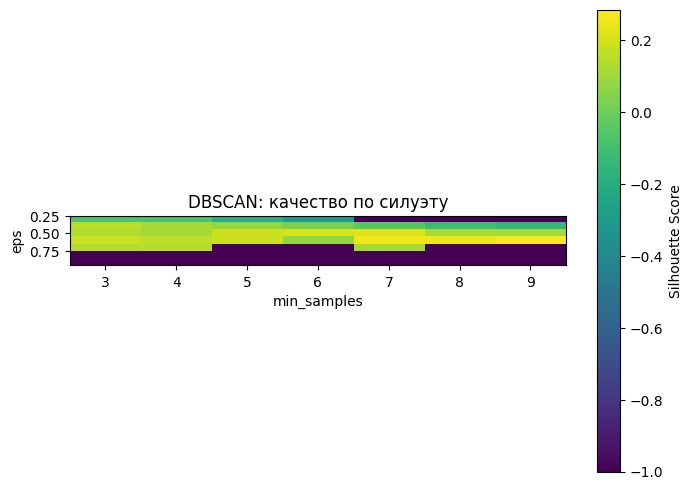

Лучшие параметры DBSCAN: eps=0.6, min_samples=9
Лучший силуэт: 0.2858


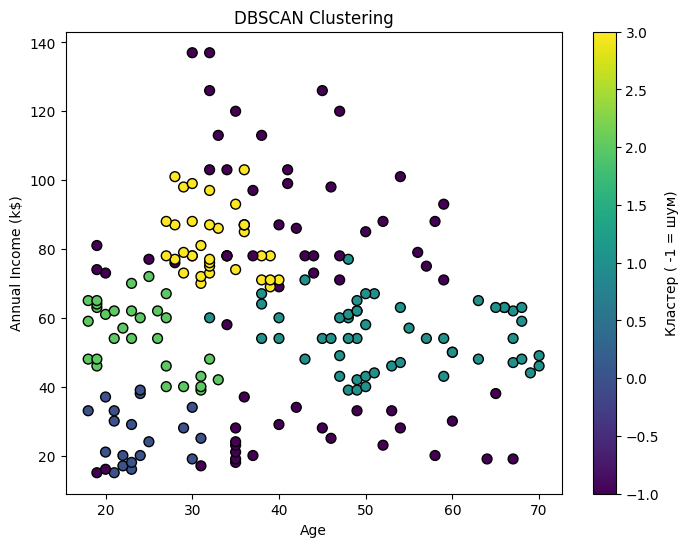

Число кластеров (без шума): 4
  Silhouette: 0.2858
  Davies-Bouldin: 1.4245
  Calinski-Harabasz: 53.0166


In [6]:
# DBSCAN
from sklearn.cluster import DBSCAN

# Диапазоны параметров
eps_values = np.arange(0.3, 1.0, 0.1)
min_samples_values = range(3, 10)

best_score = -1
best_params = None
best_labels = None

# Хранение результатов для визуализации (можно построить heatmap)
results = np.zeros((len(eps_values), len(min_samples_values)))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        # Пропускаем, если кластеров меньше 2
        if n_clusters < 2:
            results[i, j] = -1
            continue
        # Вычисляем силуэт (игнорируем шум? лучше использовать все точки, но силуэт может быть низким)
        # Для простоты считаем силуэт по всем точкам, включая шум (метка -1)
        sil = silhouette_score(X_scaled, labels)
        results[i, j] = sil
        if sil > best_score:
            best_score = sil
            best_params = (eps, min_samples)
            best_labels = labels

# Визуализация heatmap
plt.figure(figsize=(8,6))
plt.imshow(results, interpolation='nearest', cmap='viridis',
           extent=[min_samples_values[0]-0.5, min_samples_values[-1]+0.5, eps_values[-1]+0.05, eps_values[0]-0.05])
plt.colorbar(label='Silhouette Score')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.title('DBSCAN: качество по силуэту')
plt.show()

print(f"Лучшие параметры DBSCAN: eps={best_params[0]:.1f}, min_samples={best_params[1]}")
print(f"Лучший силуэт: {best_score:.4f}")

# Финальная модель с лучшими параметрами
db_best = DBSCAN(eps=best_params[0], min_samples=best_params[1])
clusters_dbscan = db_best.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = clusters_dbscan

# Визуализация
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters_dbscan, s=50, cmap='viridis', edgecolors='k')
plt.title("DBSCAN Clustering")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.colorbar(scatter, label='Кластер ( -1 = шум)')
plt.show()

# Метрики для лучшего разбиения
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
print(f"Число кластеров (без шума): {n_clusters}")
if n_clusters >= 2:
    sil = silhouette_score(X_scaled, clusters_dbscan)
    db_idx = davies_bouldin_score(X_scaled, clusters_dbscan)
    ch = calinski_harabasz_score(X_scaled, clusters_dbscan)
    print(f"  Silhouette: {sil:.4f}")
    print(f"  Davies-Bouldin: {db_idx:.4f}")
    print(f"  Calinski-Harabasz: {ch:.4f}")
else:
    print("Недостаточно кластеров для расчёта метрик.")

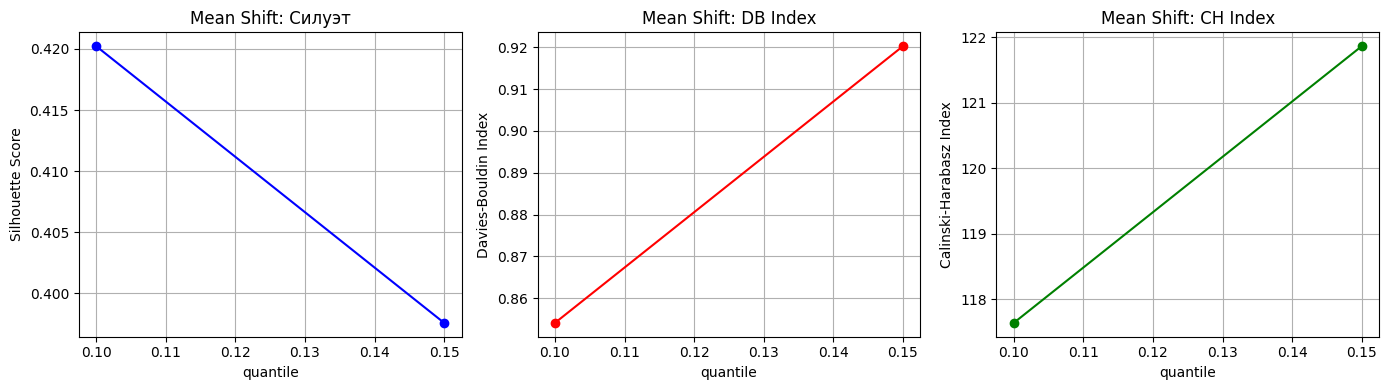

Лучший quantile: 0.10, bandwidth: 1.013
Лучший силуэт: 0.4202


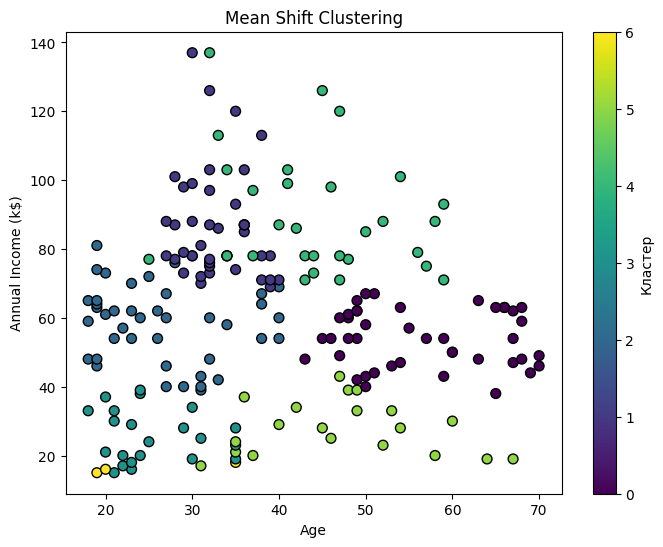

Число кластеров: 7
  Silhouette: 0.4202
  Davies-Bouldin: 0.8541
  Calinski-Harabasz: 117.6429


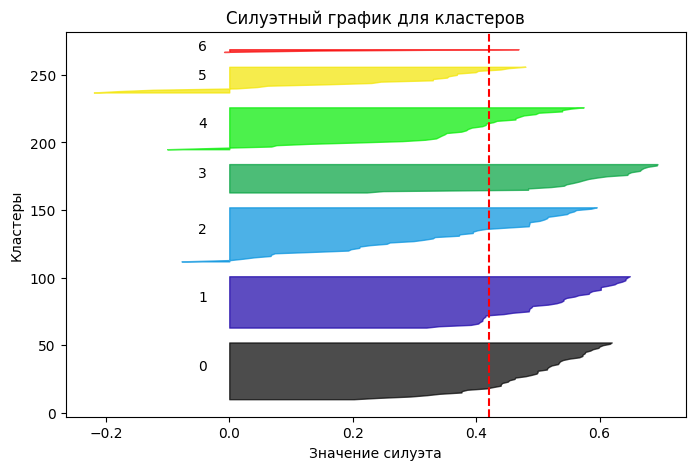

In [10]:
# Кластеризация со средним сдвигом
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

quantiles = np.arange(0.1, 0.55, 0.05)
sil_ms = []
db_ms = []
ch_ms = []
best_bandwidth = None
best_labels_ms = None
best_score = -1

for q in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=q, n_samples=100)
    if bandwidth is None or bandwidth <= 0:
        continue
    ms = MeanShift(bandwidth=bandwidth)
    labels = ms.fit_predict(X_scaled)
    n_clusters = len(set(labels))
    if n_clusters < 2:
        continue
    sil = silhouette_score(X_scaled, labels)
    sil_ms.append(sil)
    db_ms.append(davies_bouldin_score(X_scaled, labels))
    ch_ms.append(calinski_harabasz_score(X_scaled, labels))
    if sil > best_score:
        best_score = sil
        best_bandwidth = bandwidth
        best_labels_ms = labels
        best_q = q

# Визуализация зависимости от quantile
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(quantiles[:len(sil_ms)], sil_ms, 'bo-')
plt.xlabel('quantile')
plt.ylabel('Silhouette Score')
plt.title('Mean Shift: Силуэт')
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(quantiles[:len(db_ms)], db_ms, 'ro-')
plt.xlabel('quantile')
plt.ylabel('Davies-Bouldin Index')
plt.title('Mean Shift: DB Index')
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(quantiles[:len(ch_ms)], ch_ms, 'go-')
plt.xlabel('quantile')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Mean Shift: CH Index')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Лучший quantile: {best_q:.2f}, bandwidth: {best_bandwidth:.3f}")
print(f"Лучший силуэт: {best_score:.4f}")

# Финальная модель
ms_best = MeanShift(bandwidth=best_bandwidth)
clusters_ms = ms_best.fit_predict(X_scaled)
df['Cluster_MeanShift'] = clusters_ms

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=clusters_ms, s=50, cmap='viridis', edgecolors='k')
plt.title("Mean Shift Clustering")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.colorbar(label='Кластер')
plt.show()

# Метрики для лучшего разбиения
n_clusters_ms = len(set(clusters_ms))
print(f"Число кластеров: {n_clusters_ms}")
sil_final = silhouette_score(X_scaled, clusters_ms)
db_final = davies_bouldin_score(X_scaled, clusters_ms)
ch_final = calinski_harabasz_score(X_scaled, clusters_ms)
print(f"  Silhouette: {sil_final:.4f}")
print(f"  Davies-Bouldin: {db_final:.4f}")
print(f"  Calinski-Harabasz: {ch_final:.4f}")

# Вычисление силуэтов для каждой точки
sample_silhouette_values = silhouette_samples(X_scaled, clusters_ms)

# Создание фигуры
fig, ax = plt.subplots(figsize=(8, 5))

y_lower = 10
for i in range(n_clusters_ms):
    # Извлечение силуэтов для кластера i и их сортировка
    ith_cluster_silhouette_values = sample_silhouette_values[clusters_ms == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters_ms)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Подпись кластера в центре
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color="red", linestyle="--")
ax.set_title("Силуэтный график для кластеров")
ax.set_xlabel("Значение силуэта")
ax.set_ylabel("Кластеры")
plt.show()

Affinity Propagation нашёл 13 кластеров


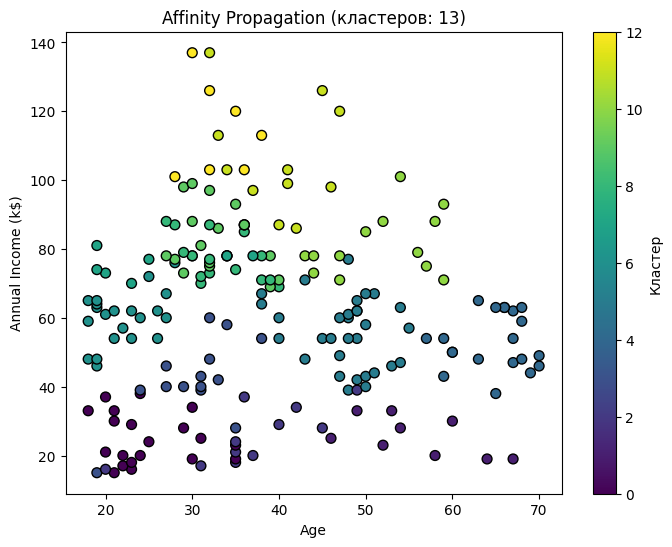

  Silhouette Score: 0.3691
  Davies-Bouldin Index: 0.9494
  Calinski-Harabasz Index: 128.6025


In [8]:
# Метод распространения близости
from sklearn.cluster import AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Affinity Propagation с параметрами по умолчанию
ap = AffinityPropagation(random_state=42)
clusters_ap = ap.fit_predict(X_scaled)
df['Cluster_AffinityProp'] = clusters_ap

# Количество найденных кластеров
n_clusters_ap = len(set(clusters_ap))
print(f"Affinity Propagation нашёл {n_clusters_ap} кластеров")

# Визуализация
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=clusters_ap, s=50, cmap='viridis', edgecolors='k')
plt.title(f"Affinity Propagation (кластеров: {n_clusters_ap})")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.colorbar(label='Кластер')
plt.show()

# Метрики качества (если кластеров >= 2)
if n_clusters_ap >= 2:
    sil = silhouette_score(X_scaled, clusters_ap)
    db = davies_bouldin_score(X_scaled, clusters_ap)
    ch = calinski_harabasz_score(X_scaled, clusters_ap)
    print(f"  Silhouette Score: {sil:.4f}")
    print(f"  Davies-Bouldin Index: {db:.4f}")
    print(f"  Calinski-Harabasz Index: {ch:.4f}")
else:
    print("Недостаточно кластеров для расчёта метрик.")

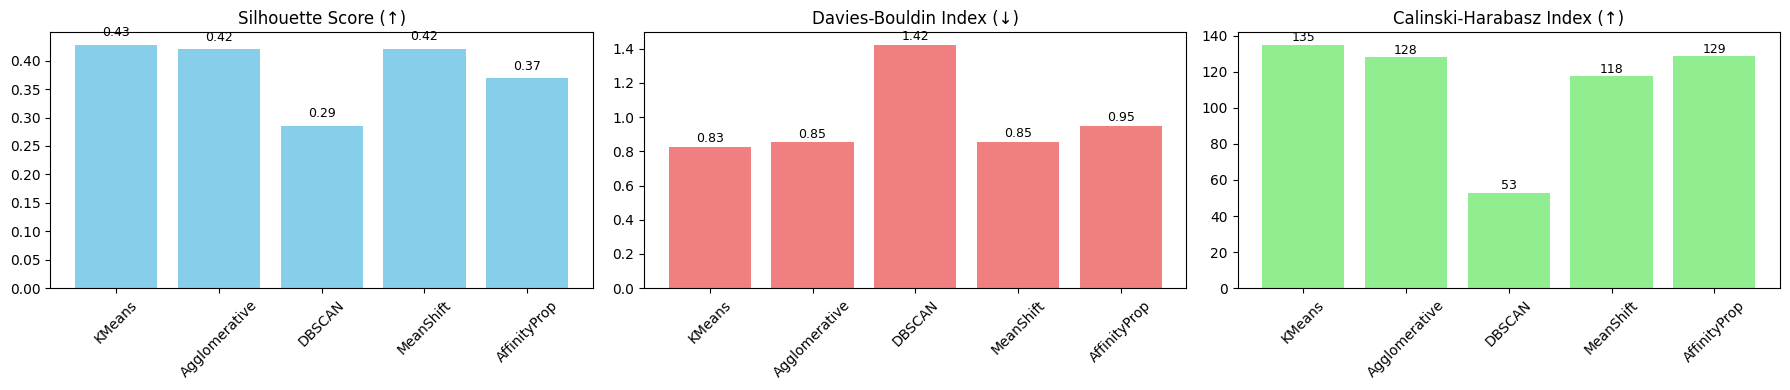

Сравнительная таблица методов кластеризации (отсортировано по силуэту):

        Метод  Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
       KMeans        0.428417            0.825354             135.102104
    MeanShift        0.420226            0.854069             117.642933
Agglomerative        0.420117            0.852102             127.986454
 AffinityProp        0.369121            0.949400             128.602469
       DBSCAN        0.285784            1.424535              53.016604

ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КЛАСТЕРИЗАЦИИ

1. Лучший метод по силуэту: **KMeans** (Silhouette = 0.4284).
   Davies-Bouldin Index = 0.8254 (чем ниже, тем лучше),
   Calinski-Harabasz Index = 135 (чем выше, тем лучше).
   Этот метод обеспечивает наиболее чёткое разделение на кластеры.

2. Худший результат у метода **DBSCAN** (Silhouette = 0.2858).
   Этот метод дал наименее качественное разбиение, возможно, из-за несоответствия предположений алгоритма структуре данных.

3. Краткая интерпрета

In [9]:
# Сравнение всех методов
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Убедитесь, что все переменные с метками кластеров определены:
# clusters_kmeans, clusters_agg, clusters_dbscan, clusters_ms, clusters_ap

method_names = ['KMeans', 'Agglomerative', 'DBSCAN', 'MeanShift', 'AffinityProp']
all_labels = [
    clusters_kmeans,
    clusters_agg,
    clusters_dbscan,
    clusters_ms,
    clusters_ap
]

sil_scores = []
db_scores = []
ch_scores = []

for labels in all_labels:
    # Проверяем, что есть хотя бы 2 кластера (иначе метрики не определены)
    if len(set(labels)) >= 2:
        sil_scores.append(silhouette_score(X_scaled, labels))
        db_scores.append(davies_bouldin_score(X_scaled, labels))
        ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    else:
        sil_scores.append(0)
        db_scores.append(0)
        ch_scores.append(0)

# Визуализация метрик
plt.figure(figsize=(18,4))

plt.subplot(1,3,1)
bars1 = plt.bar(method_names, sil_scores, color='skyblue')
plt.title('Silhouette Score (↑)')
plt.xticks(rotation=45)
for bar, val in zip(bars1, sil_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1,3,2)
bars2 = plt.bar(method_names, db_scores, color='lightcoral')
plt.title('Davies-Bouldin Index (↓)')
plt.xticks(rotation=45)
for bar, val in zip(bars2, db_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1,3,3)
bars3 = plt.bar(method_names, ch_scores, color='lightgreen')
plt.title('Calinski-Harabasz Index (↑)')
plt.xticks(rotation=45)
for bar, val in zip(bars3, ch_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Составляем таблицу результатов
results_df = pd.DataFrame({
    'Метод': method_names,
    'Silhouette (↑)': sil_scores,
    'Davies-Bouldin (↓)': db_scores,
    'Calinski-Harabasz (↑)': ch_scores
})

# Сортируем по силуэту (от лучшего к худшему)
results_df = results_df.sort_values('Silhouette (↑)', ascending=False).reset_index(drop=True)

print("Сравнительная таблица методов кластеризации (отсортировано по силуэту):\n")
print(results_df.to_string(index=False))

# Аналитические выводы
print("\n" + "="*70)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ КЛАСТЕРИЗАЦИИ")
print("="*70)

# Лучший метод
best = results_df.iloc[0]
print(f"\n1. Лучший метод по силуэту: **{best['Метод']}** (Silhouette = {best['Silhouette (↑)']:.4f}).")
print(f"   Davies-Bouldin Index = {best['Davies-Bouldin (↓)']:.4f} (чем ниже, тем лучше),")
print(f"   Calinski-Harabasz Index = {best['Calinski-Harabasz (↑)']:.0f} (чем выше, тем лучше).")
print(f"   Этот метод обеспечивает наиболее чёткое разделение на кластеры.")

# Худший метод
worst = results_df.iloc[-1]
print(f"\n2. Худший результат у метода **{worst['Метод']}** (Silhouette = {worst['Silhouette (↑)']:.4f}).")
if worst['Silhouette (↑)'] <= 0:
    print("   Отрицательный силуэт указывает на то, что объекты часто попадают не в свой кластер – метод не справился с задачей.")
else:
    print("   Этот метод дал наименее качественное разбиение, возможно, из-за несоответствия предположений алгоритма структуре данных.")

# Краткий комментарий по каждому методу
print("\n3. Краткая интерпретация:")
interpretations = {
    'KMeans': 'KMeans предполагает сферические кластеры равного размера – на наших данных работает хорошо, если кластеры близки к сферическим.',
    'Agglomerative': 'Иерархическая кластеризация гибко настраивается, но чувствительна к шуму; результат зависит от выбранного метода связи.',
    'DBSCAN': 'DBSCAN выделяет кластеры произвольной формы и помечает шум; хорошо работает при правильном подборе eps и min_samples.',
    'MeanShift': 'Mean Shift автоматически определяет число кластеров, но требует настройки bandwidth; хорошо подходит для данных с чёткими модами.',
    'AffinityProp': 'Метод распространения близости не требует задания числа кластеров, но может быть медленным на больших данных; часто даёт много мелких кластеров.'
}
for method in results_df['Метод']:
    print(f"   - {method}: {interpretations[method]}")

# Общий вывод
print(f"\n4. Общий вывод:")
print(f"   На основе сравнительного анализа для сегментации клиентов торгового центра рекомендуется использовать метод **{best['Метод']}**, так как он показал наилучшие метрики качества. Этот метод позволяет выделить группы клиентов с чёткими различиями по возрасту, доходу и покупательской активности. Остальные методы либо уступают по качеству, либо дают менее интерпретируемые результаты.")